# Region List for Hybridization Specificity Filter

When designing oligo nucleotides for custom experimental setups, those oligo nucleotides should be specific to their intended target region. We can check the specificity of the oligo to its target region by scanning a reference sequence (e.g. the genome or transcriptome) for potential off-target regions, which are regions in the reference with a sequence almost identical to the oligo target region. Those off-target regions can be identified using for instance Blast or Bowtie. However, those alignment filters can be sometimes too strict, since they only check for sequence similarity, and filter out too many oligos that have potential off-target regions. For the verification of Blast or Bowtie off-target hits, we want to compute the binding probability of the oligo nucleotide with the off-target region. The tool NUPACK provides mathematical/physics models that can compute the concentration of sequences as well as their complexes in a tube analsis, as well as the thermodynamic free energy of a complex.

While NUPACK’s `tube_analysis` or `complex_concentrations` (which computes overall binding “affinities” or concentrations in a mixture) can be informative, it is more focused on predicting the *distribution* of different complexes in a multi-component system. For simply checking whether an individual off-target site forms a stable duplex, the thermodynamic free energy, computed with NUPACK's complex free energy `free_energy`, of that particular interaction provides a more direct and interpretable metric for assessing whether a particular off-target binding interaction is sufficiently stable to matter. If an off-target duplex has a significantly negative free energy (i.e., a strongly favorable binding interaction), it is more likely to form and compete with the intended on‐target binding. More negative values mean stronger (more favorable) interactions. However, there is *no single universal cutoff* that separates “stable” from “unstable,” since this depends on experimental conditions (temperature, concentrations etc.) as well as experimental requirements (can some off-target bindings be tolerated?).

The most suited approach for our setup, is the comparison of the off-target free energy to the on-target free energy. If the off-target free energy is *substantially higher* (less negative) than the on-target binding, it's less likely to get significant off-target effects. Hence, we compute the fraction of off-target over on-target free energy $P_{off} = \frac{\Delta_G (off)}{\Delta_G (on)}$, which should be maximum $P_{off} = 1$ when the off-target sequence is exactly the same sequence as the on-target sequence. If the off-target free energy is more negative than the on-target free energy, we also set $P_{off} = 1$. If the free energy of the off-target region is above 0 it is very unlikely that the two sequences form a duplex. Hence, we would crop the off-target free energy at 0, which would lead to a minimum $P_{off} = 0$.

Our goal is now to train a knowledge destillation model that can predict the free energy of a duplex based on the complex free enrgy that is computed by NUPACK. Therefore, we need to:
1) assemble a training dataset with on and off-target sequences
2) calculate the ground truth free energy using NUPACK's `free_energy` attribute of the *complex analysis*
3) train the model to predict the free energy based on on and off-target sequence as well as experiment temperature

To generate the oligo data set, we need regions to sample from. Select 800 genes and 200 intergenic regions hat closely resemble the nucleotide percentage distribution of all genes and intergenic regions. In order to not oversample chromosomes or certain gene types, we sample the regions according to their chromomosome frequency.

Because of a bug in the intergenic region parsing, the region selection needs to be performed with the code contained in the oligo-designer-toolsuite branch `120-fix-intergenic-parsing`. This code is now also contained in the fork jonas-hag/oligo-designer-toolsuite@115-dev-current-filter-n_align (currently installed in the conda environment `odt-ai`). This branch was used in the script `generate_real_dataset_reference_db.py` where the geneic and intergenic regions were computed. The gft and fasta files from NCBI were downloaded, for the species: Homo_sapiens, release number: GCF_000001405.40-RS_2025_08 and genome assembly: GRCh38.p14.


## Function definitions and imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from oligo_designer_toolsuite.utils import FastaParser
import numpy as np
import re
from Bio.SeqUtils import gc_fraction

pd.options.mode.copy_on_write = True

/opt/miniconda3/envs/odt-ai/lib/python3.11/site-packages/seqfold/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
FILE_GENES = "../../data/hybridization_probability/datasets/reference_db/annotation/gene_annotation_source-NCBI_species-Homo_sapiens_annotation_release-GCF_000001405.40-RS_2025_08_genome_assemly-unknown.fna"
FILE_INTERGENIC = "../../data/hybridization_probability/datasets/reference_db/annotation/intergenic_annotation_source-NCBI_species-Homo_sapiens_annotation_release-GCF_000001405.40-RS_2025_08_genome_assemly-unknown.fna"

In [3]:
def nucleotide_distribution_table(seq_records):
    """
    Given a list of SeqRecords, returns a DataFrame with rows = SeqRecord IDs, and columns = %A, %C, %G, %T.
    Sequences are normalized to uppercase so both uppercase and lowercase are counted correctly.
    """
    data = []
    fasta_parser = FastaParser()
    
    for record in seq_records:
        seq_str = str(record.seq).upper()  # convert to uppercase
        length = len(seq_str)

        # Convert to percentages
        percent_a = 100.0 * seq_str.count("A") / length
        percent_c = 100.0 * seq_str.count("C") / length
        percent_g = 100.0 * seq_str.count("G") / length
        percent_t = 100.0 * seq_str.count("T") / length
        gc_content = 100.0 * gc_fraction(seq_str)

        region_id, _, coordinates = fasta_parser.parse_fasta_header(record.id, parse_coordinates=True, parse_additional_info=False)
        
        data.append([region_id, percent_a, percent_c, percent_g, percent_t, gc_content, length, coordinates["chromosome"][0], coordinates["strand"][0], coordinates["start"][0], coordinates["end"][0]])

    # Build the DataFrame with labeled columns
    df = pd.DataFrame(data, columns=["region_id", "%A", "%C", "%G", "%T", "GC_content", "length", "chromosome", "strand", "start", "end"])
    return df

def categorize_gene_type(val):
        if re.match(r'^LINC', val):
            return "LINC"
        elif re.match(r'^MIR', val):
            return "MIR"
        elif re.match(r'^MT-', val):
            return "MT"
        elif re.match(r'^RNU', val):
            return "RNU"
        elif re.match(r'^RPL', val):
            return "RPL"
        elif re.match(r'^RPS', val):
            return "RPS"
        elif re.match(r'^SNO', val):
            return "SNO"
        else:
            return "Other"
        
def plot_nucleotide_distributions(df, category_value=None, category_type=None):
    """
    Given a DataFrame with columns: region_id, %A, %C, %G, %T
    create a distribution plot (histogram or KDE) 
    for the distribution of percentages of each nucleotide across regions.
    """

        
    # intergenic regions are also classified as "Other"
    df["gene_type"] = df["region_id"].apply(categorize_gene_type)

    if category_value is not None:
        if category_type is None:
            raise ValueError("category_type must be specified when category_value is provided.")
        else:
            df = df[df[category_type] == category_value]

    # Melt the wide table into long form:
    # from columns [%A, %C, %G, %T] -> rows labeled by 'nucleotide' and 'percentage'
    df_long = df.melt(
        id_vars="region_id",
        value_vars=["%A", "%C", "%G", "%T", "GC_content"],
        var_name="nucleotide",
        value_name="percentage"
    )

    # Plot with seaborn: one distribution per nucleotide (overlapping)
    sns.displot(
        data=df_long,
        x="percentage",
        hue="nucleotide",
        kind="kde",  # or "hist" for histograms
        fill=True
    )

    plt.title("Distribution of Nucleotide Percentages")
    plt.xlabel("Nucleotide Percentage")
    plt.xlim([0, 100])
    plt.tight_layout()
    plt.show()

def plot_chromosome_distribution(df, regions=None, only_common_chromosomes=False):
    """
    Given a DataFrame with columns: region_id, chromosome and a list of regions,
    create a bar plot showing the distribution of chromosomes.
    """
    
    if regions is not None:
        df_plot = df[df["region_id"].isin(regions)]
    else:
        df_plot = df
    
    if only_common_chromosomes:
        common_chromosomes = [str(i) for i in range(1, 23)] + ['X', 'Y']
        df_plot = df_plot[df_plot['chromosome'].isin(common_chromosomes)]

    plt.figure(figsize=(12, 4))
    order_labels = sorted(df_plot['chromosome'].unique())
    chr_list = [str(i) for i in range(1, 23)]
    order_labels = chr_list + [x for x in order_labels if x not in chr_list]  # Ensure chromosomes 1-22 are first
    sns.countplot(df_plot, x="chromosome", order=order_labels)

    plt.title("Chromosome distribution")
    plt.xlabel("Chromosome")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

def plot_nucleotide_category_distribution(df, category_value, category_type="gene_type", additional_title=None, add_data=None):
    """
    Given a DataFrame with columns: region_id, and a list of regions,
    create a bar plot showing the distribution of certain gene categories.
    """
    
    if category_type == "gene_type":
        df["gene_type"] = df["region_id"].apply(categorize_gene_type)
        df = df[df["gene_type"] == category_value]
    elif category_type == "chromosome":
        df = df.merge(add_data, on="region_id", how="left")
        df = df[df["chromosome"] == category_value]
    else:
        raise ValueError("category_type must be either 'gene_type' or 'chromosome'.")
    # plt.figure(figsize=(12, 4))
    ax = sns.countplot(df, x="nucleotide_category")

    # calculate the percentage for each category
    total = df["nucleotide_category"].count()
    for c in ax.containers:
        ax.bar_label(c, fmt=lambda x: f'{(x/total)*100:0.1f}%')

    # add space at the end of the bar for the labels
    ax.margins(x=0.1)
    if additional_title is not None:
        plt.title(f"Nucleotide type distribution for {category_type} {category_value} - {additional_title}")
    else:
        plt.title(f"Gene type distribution for {category_type} {category_value}")
    plt.xlabel("Gene Type")
    plt.tight_layout()
    plt.show()

def plot_strand_distribution(df, regions=None):
    """
    Given a DataFrame with columns: region_id, strand and a list of regions,
    create a bar plot showing the distribution of strands.
    """
    
    if regions is not None:
        df_plot = df[df["region_id"].isin(regions)]
    else:
        df_plot = df
    sns.countplot(df_plot, x="strand")

    plt.title("Strand distribution")
    plt.xlabel("Strand")
    plt.tight_layout()
    plt.show()

def plot_gene_type_distribution(df, regions=None, additional_title=None):
    """
    Given a DataFrame with columns: region_id, and a list of regions,
    create a bar plot showing the distribution of certain gene categories.
    """
    
    if regions is not None:
        df_plot = df[df["region_id"].isin(regions)]
    else:
        df_plot = df
        
    df_plot["gene_type"] = df_plot["region_id"].apply(categorize_gene_type)
    # plt.figure(figsize=(12, 4))
    ax = sns.countplot(df_plot, x="gene_type")

    # calculate the percentage for each category
    total = df_plot["gene_type"].count()
    for c in ax.containers:
        ax.bar_label(c, fmt=lambda x: f'{(x/total)*100:0.1f}%')

    # add space at the end of the bar for the labels
    ax.margins(x=0.1)
    if additional_title is not None:
        plt.title(f"Gene type distribution - {additional_title}")
    else:
        plt.title("Gene type distribution")
    plt.xlabel("Gene Type")
    plt.tight_layout()
    plt.show()



## Genes
### Read in the data

In [4]:
fasta_parser = FastaParser()
sequences = fasta_parser.read_fasta_sequences(file_fasta_in=FILE_GENES)

print(f"Loaded {len(sequences)} gene regions.")

Loaded 67512 gene regions.


Remove all sequences that contain "N" nucleotides.

In [5]:
sequences_filtered = []

for sequence in sequences:
    if not "N" in sequence.seq:
        sequences_filtered.append(sequence)

print(f"Removed {len(sequences) - len(sequences_filtered)} sequences.")

Removed 82 sequences.


Calculate the proportions of nucleotides for each gene sequences.

In [6]:
table_nucleotides_gene = nucleotide_distribution_table(sequences_filtered)

In [7]:
n_genes_pre_filtering = table_nucleotides_gene.shape[0]

Remove all sequences that are shorter than 124 nucleotides as this is the minimum length needed for oligo generation later on.

In [8]:
table_nucleotides_gene = table_nucleotides_gene[table_nucleotides_gene["length"] >= 124]

In [9]:
print(f"Removed {n_genes_pre_filtering - table_nucleotides_gene.shape[0]} sequences.")

Removed 6690 sequences.


### Data properties

Check that there are no duplicates:

In [10]:
table_nucleotides_gene[table_nucleotides_gene.duplicated(subset=["region_id"], keep=False)]

,region_id,%A,%C,%G,%T,GC_content,length,chromosome,strand,start,end


And check out the distribution of nucleotide fractions.

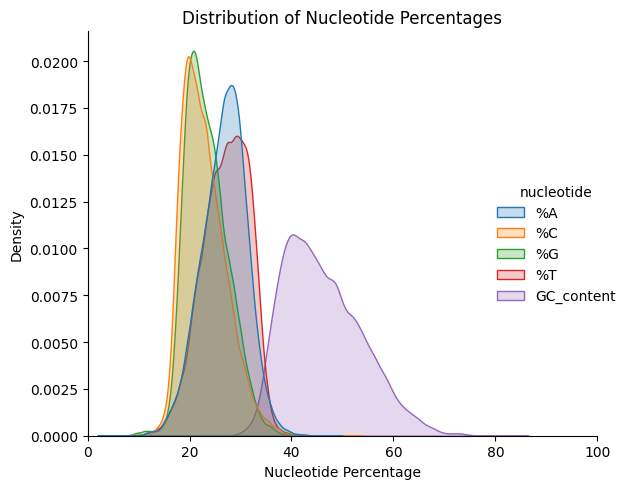

In [11]:
plot_nucleotide_distributions(table_nucleotides_gene)

Show the fraction of the different chromosomes:

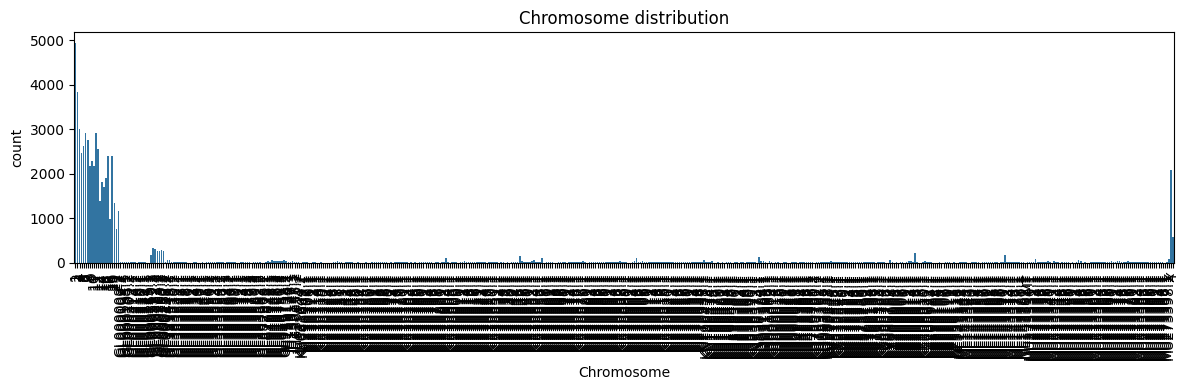

In [12]:
plot_chromosome_distribution(table_nucleotides_gene)

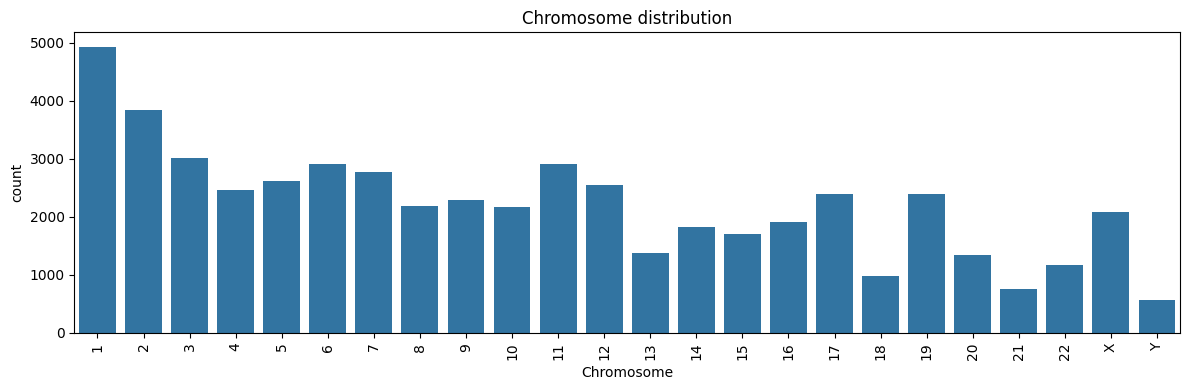

In [13]:
plot_chromosome_distribution(table_nucleotides_gene, only_common_chromosomes=True)

In [14]:
chromosome_info = table_nucleotides_gene["chromosome"].value_counts().reset_index()
chromosome_info["fraction"] = chromosome_info["count"] / table_nucleotides_gene.shape[0]

### Sample regions

Randomly sample a region, then accept it with the probability how often its chromosome is contained in the whole data set:

- randomly sample a region
- sample from a binomial distribution with the probabilty of success according to the percentage how often the chromosome of the region is contained in the whole data set
- if the random number from the bionomial distribution is 1, accept the region, otherwise reject it
- repeat the above steps until enough regions are sampled

In [15]:
prng_selection = np.random.RandomState(2223764389)
prng_selection_binomial = np.random.default_rng(7467234563)
selected_genes = []
while len(selected_genes) < 800:
    one_sample = table_nucleotides_gene.sample(n=1, random_state=prng_selection)

    if one_sample["region_id"].values[0] in selected_genes:
        continue

    # extract the chromosome and its frequency
    chromosome = one_sample["chromosome"].values[0]
    chromosome_frequency = chromosome_info[chromosome_info["chromosome"] == chromosome]["fraction"].values[0]
    random_number_for_decision = prng_selection_binomial.binomial(n=1, p=chromosome_frequency)

    if random_number_for_decision == 1:
        selected_genes.append(one_sample["region_id"].values[0])
    else:
        continue    



### Properties of selected genes

Inspect the nucleotide distribution of the sample:

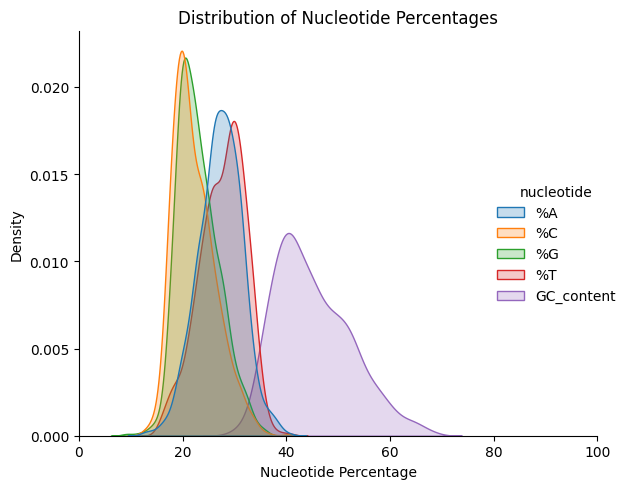

In [16]:
df_selected_genes = pd.DataFrame(selected_genes, columns=["region_id"])
df_selected_genes_data = df_selected_genes.merge(table_nucleotides_gene, on="region_id", how="left")
plot_nucleotide_distributions(df_selected_genes_data)

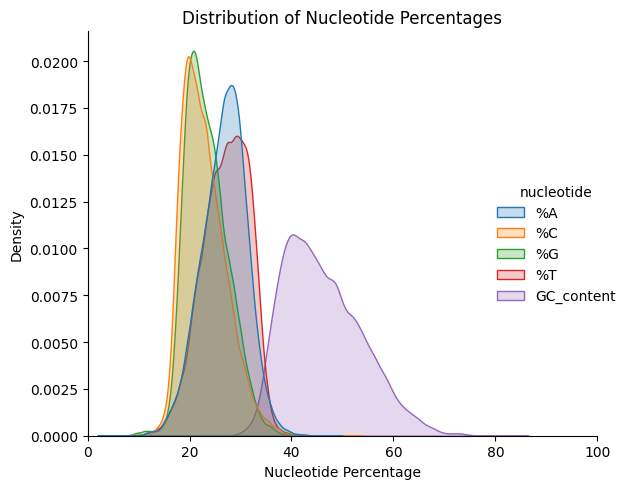

In [17]:
# as comparison the whole dataset
plot_nucleotide_distributions(table_nucleotides_gene)

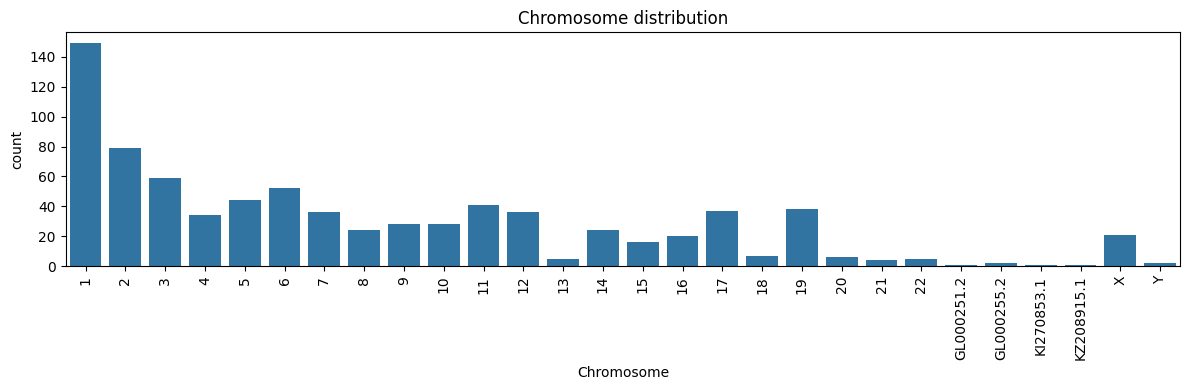

In [18]:
plot_chromosome_distribution(df_selected_genes_data)

Check the distribution of gene categories:

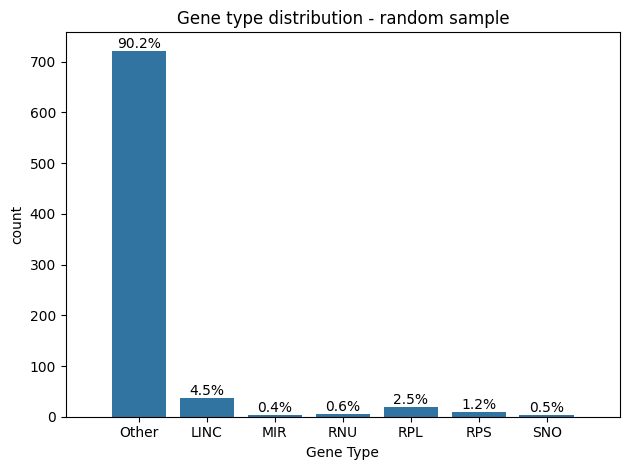

In [19]:
plot_gene_type_distribution(table_nucleotides_gene, selected_genes, "random sample")

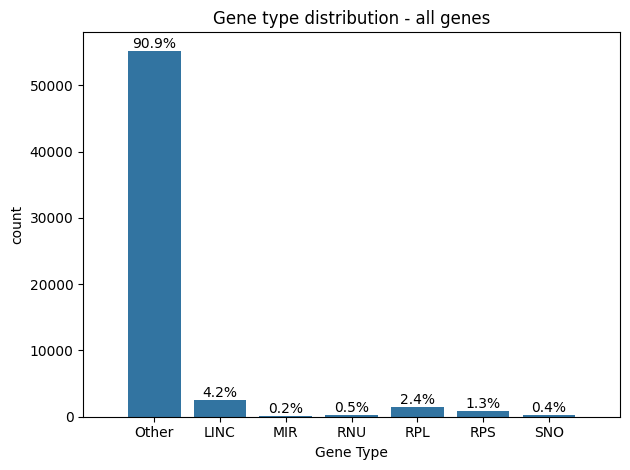

In [20]:
plot_gene_type_distribution(table_nucleotides_gene, additional_title="all genes")

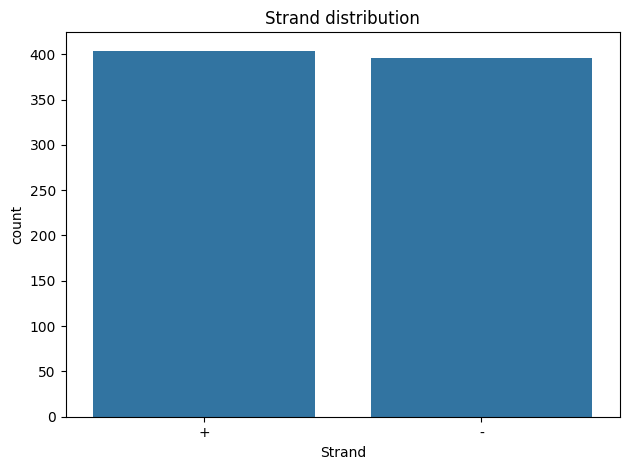

In [21]:
plot_strand_distribution(table_nucleotides_gene, selected_genes)

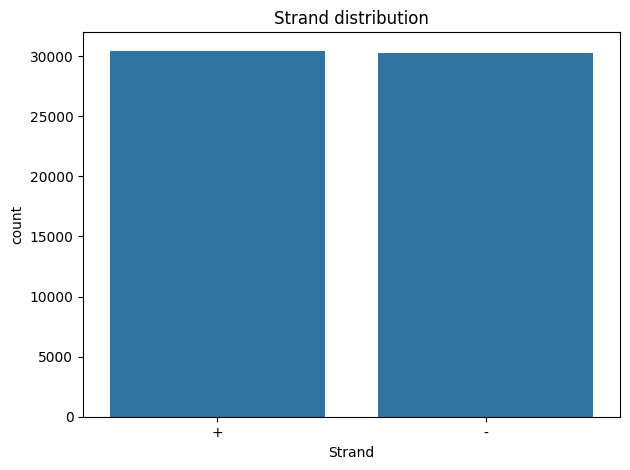

In [22]:
# all genes
plot_strand_distribution(table_nucleotides_gene)

## Intergenic regions
### Read in the data

In [23]:
fasta_parser = FastaParser()
sequences = fasta_parser.read_fasta_sequences(file_fasta_in=FILE_INTERGENIC)

print(f"Loaded {len(sequences)} intergenic regions.")

Loaded 57584 intergenic regions.


Remove all sequences that contain "N" nucleotides.

In [24]:
sequences_filtered = []

for sequence in sequences:
    if not "N" in sequence.seq:
        sequences_filtered.append(sequence)

print(f"Removed {len(sequences) - len(sequences_filtered)} sequences.")

Removed 634 sequences.


Calculate the proportions of nucleotides for each gene sequences and plot them.

In [25]:
table_nucleotides_intergenic = nucleotide_distribution_table(sequences_filtered)

In [26]:
n_intergenic_pre_filtering = table_nucleotides_intergenic.shape[0]

Remove all sequences that are shorter than 124 nucleotides as this is the minimum length needed for oligo generation later on.

In [27]:
table_nucleotides_intergenic = table_nucleotides_intergenic[table_nucleotides_intergenic["length"] >= 124]

In [28]:
print(f"Removed {n_intergenic_pre_filtering - table_nucleotides_intergenic.shape[0]} sequences.")

Removed 400 sequences.


### Data properties

Check that there are no duplicates:

In [29]:
table_nucleotides_intergenic[table_nucleotides_intergenic.duplicated(subset=["region_id"], keep=False)]

,region_id,%A,%C,%G,%T,GC_content,length,chromosome,strand,start,end


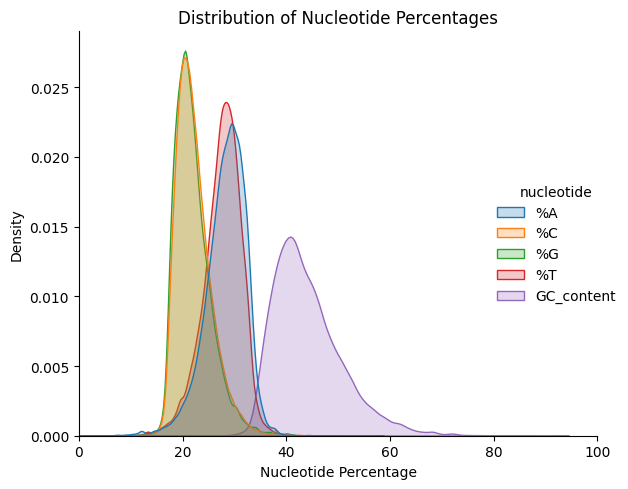

In [30]:
plot_nucleotide_distributions(table_nucleotides_intergenic)

Show the fraction of the different chromosomes:

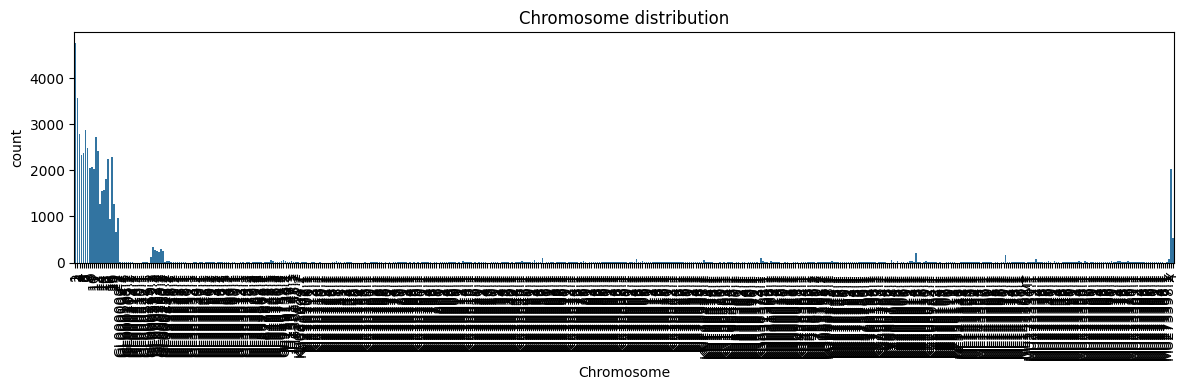

In [31]:
plot_chromosome_distribution(table_nucleotides_intergenic)

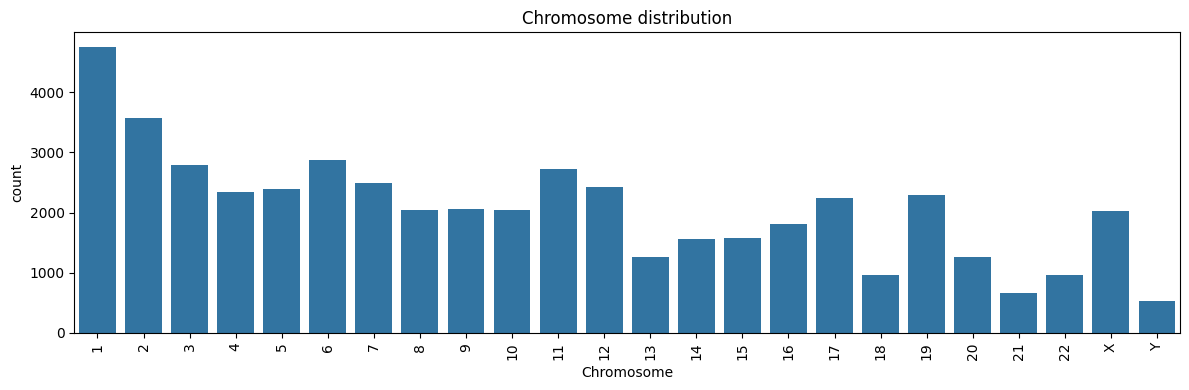

In [32]:
plot_chromosome_distribution(table_nucleotides_intergenic, only_common_chromosomes=True)

In [33]:
chromosome_info_intergenic = table_nucleotides_intergenic["chromosome"].value_counts().reset_index()
chromosome_info_intergenic["fraction"] = chromosome_info_intergenic["count"] / table_nucleotides_intergenic.shape[0]

### Sample regions

In [34]:
prng_selection_intergenic = np.random.RandomState(2223764335)
prng_selection_binomial_intergenic = np.random.default_rng(7467234503)
selected_intergenic = []
while len(selected_intergenic) < 200:
    one_sample = table_nucleotides_intergenic.sample(n=1, random_state=prng_selection_intergenic)

    if one_sample["region_id"].values[0] in selected_intergenic:
        continue

    # extract the chromosome and its frequency
    chromosome = one_sample["chromosome"].values[0]
    chromosome_frequency = chromosome_info_intergenic[chromosome_info_intergenic["chromosome"] == chromosome]["fraction"].values[0]
    random_number_for_decision = prng_selection_binomial_intergenic.binomial(n=1, p=chromosome_frequency)

    if random_number_for_decision == 1:
        selected_intergenic.append(one_sample["region_id"].values[0])
    else:
        continue    



### Properties of selected intergenic regions

Inspect the nucleotide distribution of the sample:

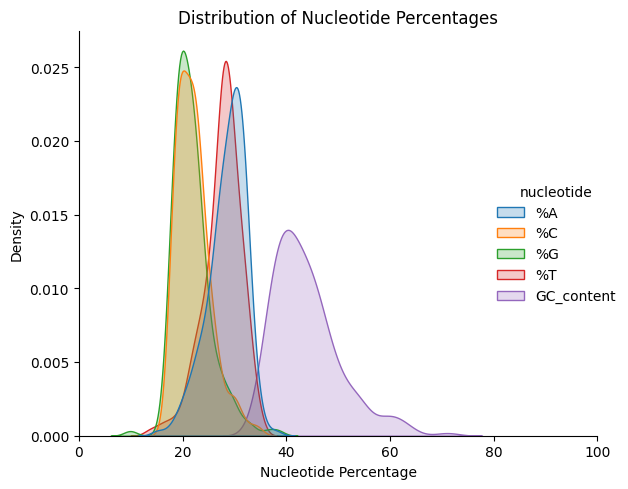

In [35]:
df_selected_intergenic = pd.DataFrame(selected_intergenic, columns=["region_id"])
df_selected_intergenic_data = df_selected_intergenic.merge(table_nucleotides_intergenic, on="region_id", how="left")
plot_nucleotide_distributions(df_selected_intergenic_data)

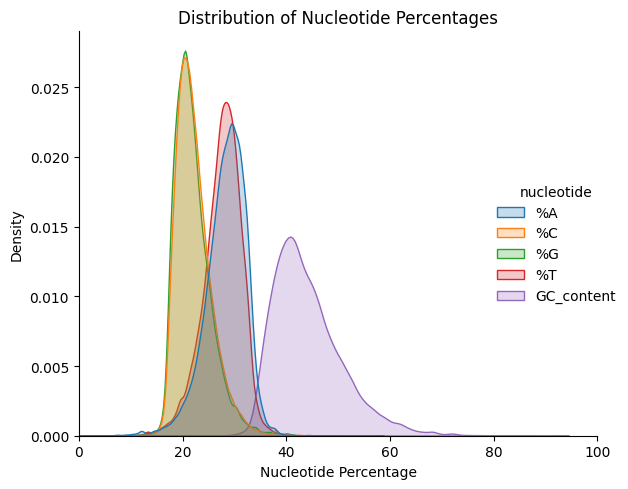

In [36]:
plot_nucleotide_distributions(table_nucleotides_intergenic)

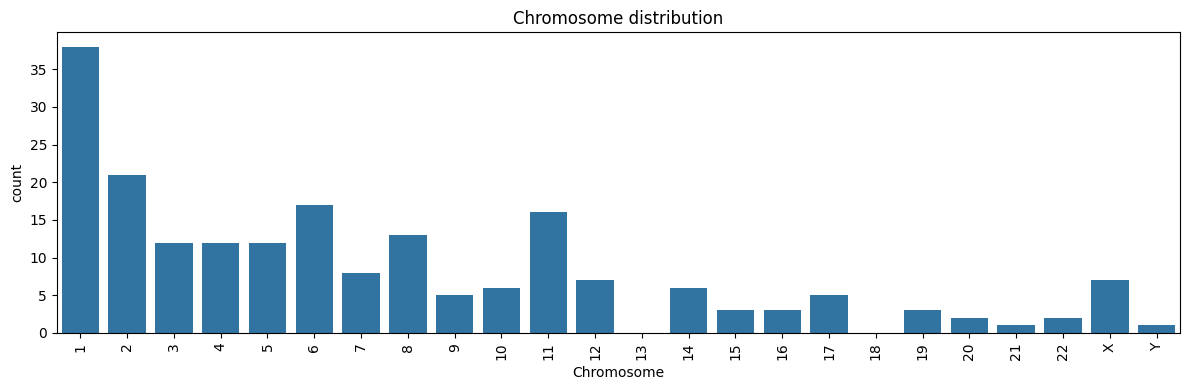

In [37]:
plot_chromosome_distribution(df_selected_intergenic_data)

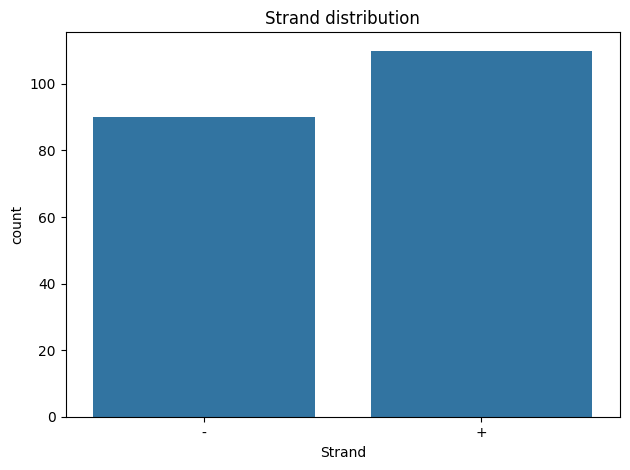

In [38]:
plot_strand_distribution(table_nucleotides_intergenic, selected_intergenic)

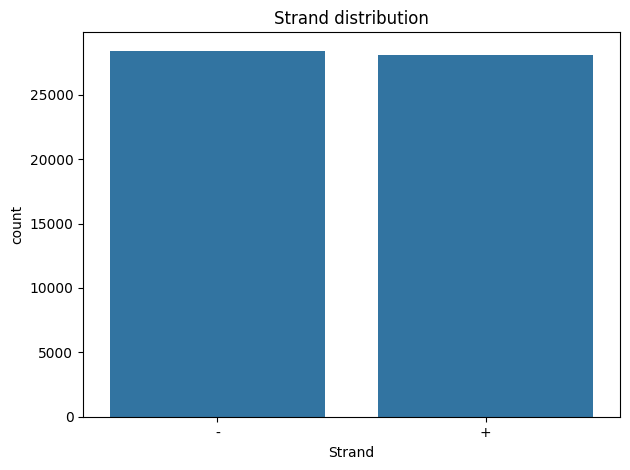

In [39]:
plot_strand_distribution(table_nucleotides_intergenic)

## Store the data

In [40]:
list_regions = sorted(selected_genes) + sorted(selected_intergenic)
list_region_type = ["gene"] * len(selected_genes) + ["intergenic"] * len(selected_intergenic)
df_regions = pd.DataFrame({"region_id": list_regions, "region_type": list_region_type})

print(f"We selected {len(list_regions)} regions in total.")

df_regions.to_csv("../../data/hybridization_probability/regions/custom_1000.csv", index=False) 

We selected 1000 regions in total.
